# F-01 — Sen1Floods11 Data Inspection

## Objective

This experiment investigates the structure and characteristics of the
Sen1Floods11 flood-mapping dataset before building any machine-learning
model.

The purpose is to understand:

- What one sample contains
- Sentinel-1 input data
- Flood labels
- Image dimensions
- Number of samples
- Class distribution
- Missing or invalid values
- Spatial and temporal information
- Differences between training, validation and test data

## Research Principle

No model training is performed in this notebook.

The dataset must be understood before selecting preprocessing,
features, baselines or machine-learning models.

## Experiment ID

F-01

## Status

Data inspection stage.

## Why this experiment comes first

A satellite dataset is not simply a collection of images.

Each sample may contain:

- satellite observations,
- spatial pixels,
- labels,
- geographic information,
- acquisition information,
- and a particular flood event.

Before training a model, we need to understand what these
represent and whether the dataset structure can support a fair
evaluation.

This inspection will therefore guide the later baseline experiment.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

NumPy version: 2.1.3
Pandas version: 2.2.3


## 1. Locate the dataset

The next step is to identify the exact local location of the
Sen1Floods11 dataset.

Do not assume the folder structure.

We will inspect the actual files first.

In [2]:
import os

DATA_ROOT = "/content/sen1floods11"

os.makedirs(DATA_ROOT, exist_ok=True)

print("Created:", DATA_ROOT)
print("Exists:", os.path.exists(DATA_ROOT))

Created: /content/sen1floods11
Exists: True


In [3]:
!gsutil ls gs://sen1floods11/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/


In [4]:
!gsutil ls gs://sen1floods11/v1.1/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/Sen1Floods11_Metadata.geojson
gs://sen1floods11/v1.1/catalog.zip
gs://sen1floods11/v1.1/catalog/
gs://sen1floods11/v1.1/checkpoints/
gs://sen1floods11/v1.1/data/
gs://sen1floods11/v1.1/splits/


In [5]:
!gsutil ls gs://sen1floods11/v1.1/splits/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/splits/flood_handlabeled/
gs://sen1floods11/v1.1/splits/perm_water/


In [6]:
!gsutil ls gs://sen1floods11/v1.1/splits/flood_handlabeled/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_bolivia_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv


In [7]:
!gsutil ls -r gs://sen1floods11/v1.1/splits/flood_handlabeled/ | head -50

gs://sen1floods11/v1.1/splits/flood_handlabeled/:
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_bolivia_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv


In [8]:
!gsutil ls gs://sen1floods11/v1.1/data/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/data/flood_events/
gs://sen1floods11/v1.1/data/perm_water/


In [9]:
!gsutil ls -r gs://sen1floods11/v1.1/data/ | head -50

gs://sen1floods11/v1.1/data/:

gs://sen1floods11/v1.1/data/flood_events/:

gs://sen1floods11/v1.1/data/flood_events/HandLabeled/:

gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/:
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_103757_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_129334_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_195474_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_23014_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_233925_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_242570_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_290290_JRCWaterHand.tif
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/JRCWaterHand/Bolivia_294583_JRCWaterHand.tif
gs://sen1floods11/

## 2. Inspect the dataset split files

The Sen1Floods11 repository provides predefined split files for the
hand-labeled flood dataset.

These files are important because they define which samples belong to
training, validation and testing.

We will inspect the CSV structure before downloading individual image
samples.

The goal is to determine:

- what columns are provided,
- how samples are identified,
- how input and label files are referenced,
- how the train/validation/test split is represented,
- and whether geographic or event information is available.

In [10]:
import pandas as pd
import subprocess
import os

# Google Cloud Storage paths
SPLIT_ROOT = "gs://sen1floods11/v1.1/splits/flood_handlabeled"

# Local Colab directory
LOCAL_SPLIT_DIR = "/content/sen1floods11/splits"
os.makedirs(LOCAL_SPLIT_DIR, exist_ok=True)

# Download the four small CSV split files
files = {
    "train": "flood_train_data.csv",
    "valid": "flood_valid_data.csv",
    "test": "flood_test_data.csv",
    "bolivia": "flood_bolivia_data.csv"
}

for name, filename in files.items():
    source = f"{SPLIT_ROOT}/{filename}"
    destination = f"{LOCAL_SPLIT_DIR}/{filename}"

    print(f"Downloading {filename}...")

    subprocess.run(
        ["gsutil", "cp", source, destination],
        check=True
    )

print("\nAll split files downloaded successfully.")


All split files downloaded successfully.


In [11]:
import pandas as pd
import os

train_path = "/content/sen1floods11/splits/flood_train_data.csv"
valid_path = "/content/sen1floods11/splits/flood_valid_data.csv"
test_path = "/content/sen1floods11/splits/flood_test_data.csv"
bolivia_path = "/content/sen1floods11/splits/flood_bolivia_data.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
test_df = pd.read_csv(test_path)
bolivia_df = pd.read_csv(bolivia_path)

print("Train shape      :", train_df.shape)
print("Validation shape :", valid_df.shape)
print("Test shape       :", test_df.shape)
print("Bolivia shape    :", bolivia_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

Train shape      : (251, 2)
Validation shape : (88, 2)
Test shape       : (89, 2)
Bolivia shape    : (14, 2)

Train columns:
['Ghana_103272_S1Hand.tif', 'Ghana_103272_LabelHand.tif']


In [12]:
# Display all columns instead of hiding some of them
pd.set_option("display.max_columns", None)

# Allow long file paths/text to be displayed completely
pd.set_option("display.max_colwidth", 200)

# Show the first 5 training samples
print("First 5 training samples:")
display(train_df.head())

First 5 training samples:


,Ghana_103272_S1Hand.tif,Ghana_103272_LabelHand.tif
0,Ghana_24858_S1Hand.tif,Ghana_24858_LabelHand.tif
1,Ghana_147015_S1Hand.tif,Ghana_147015_LabelHand.tif
2,Ghana_953791_S1Hand.tif,Ghana_953791_LabelHand.tif
3,Ghana_154838_S1Hand.tif,Ghana_154838_LabelHand.tif
4,Ghana_134751_S1Hand.tif,Ghana_134751_LabelHand.tif


In [13]:
# Count how many samples are available in each dataset split.
# Train      -> used later to train the model
# Validation -> used later to tune/select the model
# Test       -> used later for final evaluation
# Bolivia    -> a separate geographic/event subset provided by the dataset

print("Number of samples")
print("-----------------")

print("Training samples   :", len(train_df))
print("Validation samples :", len(valid_df))
print("Test samples       :", len(test_df))
print("Bolivia samples    :", len(bolivia_df))

Number of samples
-----------------
Training samples   : 251
Validation samples : 88
Test samples       : 89
Bolivia samples    : 14


In [14]:
# Compare the columns available in each split.
# This checks whether train, validation and test
# follow the same data structure.

print("Train columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(valid_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nAre Train and Validation columns identical?")
print(train_df.columns.tolist() == valid_df.columns.tolist())

print("\nAre Train and Test columns identical?")
print(train_df.columns.tolist() == test_df.columns.tolist())

Train columns:
['Ghana_103272_S1Hand.tif', 'Ghana_103272_LabelHand.tif']

Validation columns:
['Ghana_5079_S1Hand.tif', 'Ghana_5079_LabelHand.tif']

Test columns:
['Ghana_313799_S1Hand.tif', 'Ghana_313799_LabelHand.tif']

Are Train and Validation columns identical?
False

Are Train and Test columns identical?
False


In [15]:
# Check whether any CSV fields are missing.
# Missing values are represented as NaN by pandas.

print("Missing values in training split:")
print(train_df.isna().sum())

print("\nTotal missing values in training split:")
print(train_df.isna().sum().sum())

Missing values in training split:
Ghana_103272_S1Hand.tif       0
Ghana_103272_LabelHand.tif    0
dtype: int64

Total missing values in training split:
0


In [16]:
# Check whether the training CSV contains duplicate rows.
# A duplicate row means the exact same record appears more than once.

duplicate_count = train_df.duplicated().sum()

print("Duplicate rows in training CSV:", duplicate_count)

Duplicate rows in training CSV: 0


In [17]:
# Inspect the first 5 rows of the training CSV.
#
# We already know that the column names are filenames.
# Now we need to see what is stored inside those columns.
#
# This will tell us how the CSV connects an example
# to its Sentinel-1 image and its flood-label image.

print("First 5 rows of the training split:")
display(train_df.head())

First 5 rows of the training split:


,Ghana_103272_S1Hand.tif,Ghana_103272_LabelHand.tif
0,Ghana_24858_S1Hand.tif,Ghana_24858_LabelHand.tif
1,Ghana_147015_S1Hand.tif,Ghana_147015_LabelHand.tif
2,Ghana_953791_S1Hand.tif,Ghana_953791_LabelHand.tif
3,Ghana_154838_S1Hand.tif,Ghana_154838_LabelHand.tif
4,Ghana_134751_S1Hand.tif,Ghana_134751_LabelHand.tif


In [18]:
# Print the first training row as a Python dictionary.
#
# This makes it easier to understand exactly
# what information one record contains.

print("First training record:")
print(train_df.iloc[0].to_dict())

First training record:
{'Ghana_103272_S1Hand.tif': 'Ghana_24858_S1Hand.tif', 'Ghana_103272_LabelHand.tif': 'Ghana_24858_LabelHand.tif'}


In [19]:
# Show the data type of every CSV column.
#
# This helps us understand whether the entries are
# strings (file references), numbers, or something else.

print("Training CSV data types:")
print(train_df.dtypes)

Training CSV data types:
Ghana_103272_S1Hand.tif       object
Ghana_103272_LabelHand.tif    object
dtype: object


In [20]:
# ------------------------------------------------------------
# F-01 | Inspect one training record
# ------------------------------------------------------------
# Each row should represent information associated with a
# training sample.
#
# We are printing the first row as a dictionary so that we
# can clearly see what values are stored under each filename
# column.
# ------------------------------------------------------------

first_record = train_df.iloc[0].to_dict()

print("First training record:")
print(first_record)

First training record:
{'Ghana_103272_S1Hand.tif': 'Ghana_24858_S1Hand.tif', 'Ghana_103272_LabelHand.tif': 'Ghana_24858_LabelHand.tif'}


In [21]:
# ------------------------------------------------------------
# F-01 | Check CSV data types
# ------------------------------------------------------------
# This tells us whether the values stored in the CSV are
# strings, numbers, or another type.
# ------------------------------------------------------------

print("Training CSV data types:")
print(train_df.dtypes)

Training CSV data types:
Ghana_103272_S1Hand.tif       object
Ghana_103272_LabelHand.tif    object
dtype: object


In [22]:
# ------------------------------------------------------------
# F-01 | Inspect individual CSV values
# ------------------------------------------------------------
# We look at the first value stored under each column.
# This helps us distinguish between:
#
#   filename/path information
#   numeric information
#   label information
# ------------------------------------------------------------

for column in train_df.columns:
    print("Column :", column)
    print("Value  :", train_df.iloc[0][column])
    print("Type   :", type(train_df.iloc[0][column]))
    print("-" * 60)

Column : Ghana_103272_S1Hand.tif
Value  : Ghana_24858_S1Hand.tif
Type   : <class 'str'>
------------------------------------------------------------
Column : Ghana_103272_LabelHand.tif
Value  : Ghana_24858_LabelHand.tif
Type   : <class 'str'>
------------------------------------------------------------


In [23]:
# ------------------------------------------------------------
# F-01 | Inspect training sample file references
# ------------------------------------------------------------
# The CSV columns appear to contain filenames.
# We now collect the unique values stored in each column.
#
# This helps us understand whether each row corresponds to
# a Sentinel-1 image and a matching flood-label image.
# ------------------------------------------------------------

for column in train_df.columns:
    print("=" * 70)
    print("COLUMN:", column)
    print("Number of unique values:", train_df[column].nunique())

    print("\nFirst 10 values:")
    print(train_df[column].head(10).to_string(index=False))

COLUMN: Ghana_103272_S1Hand.tif
Number of unique values: 251

First 10 values:
 Ghana_24858_S1Hand.tif
Ghana_147015_S1Hand.tif
Ghana_953791_S1Hand.tif
Ghana_154838_S1Hand.tif
Ghana_134751_S1Hand.tif
 Ghana_61925_S1Hand.tif
Ghana_156478_S1Hand.tif
Ghana_144050_S1Hand.tif
 Ghana_49890_S1Hand.tif
 Ghana_97516_S1Hand.tif
COLUMN: Ghana_103272_LabelHand.tif
Number of unique values: 251

First 10 values:
 Ghana_24858_LabelHand.tif
Ghana_147015_LabelHand.tif
Ghana_953791_LabelHand.tif
Ghana_154838_LabelHand.tif
Ghana_134751_LabelHand.tif
 Ghana_61925_LabelHand.tif
Ghana_156478_LabelHand.tif
Ghana_144050_LabelHand.tif
 Ghana_49890_LabelHand.tif
 Ghana_97516_LabelHand.tif


In [24]:
# ------------------------------------------------------------
# F-01 | Locate one sample in the official Sen1Floods11 data
# ------------------------------------------------------------
# We take the first filename from the first training record
# and search the official bucket for that filename.
#
# We are NOT downloading the image yet.
# We are only locating it.
# ------------------------------------------------------------

first_s1_file = train_df.iloc[0, 0]
first_label_file = train_df.iloc[0, 1]

print("Sentinel-1 filename:", first_s1_file)
print("Label filename     :", first_label_file)

print("\nSearching for Sentinel-1 file...")
!gsutil ls -r gs://sen1floods11/v1.1/data/ | grep "{first_s1_file}" | head -10

print("\nSearching for label file...")
!gsutil ls -r gs://sen1floods11/v1.1/data/ | grep "{first_label_file}" | head -10

Sentinel-1 filename: Ghana_24858_S1Hand.tif
Label filename     : Ghana_24858_LabelHand.tif

Searching for Sentinel-1 file...
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Ghana_24858_S1Hand.tif

Searching for label file...
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Ghana_24858_LabelHand.tif


In [25]:
# ------------------------------------------------------------
# F-01 | Inspect training sample references
# ------------------------------------------------------------
# The training CSV contains two filename-related columns.
# We will inspect the values stored inside those columns.
#
# This helps us understand how Sen1Floods11 connects:
#
#   Sentinel-1 observation  <->  Flood label
#
# before we download any image.
# ------------------------------------------------------------

for column in train_df.columns:
    print("=" * 70)
    print("COLUMN:", column)

    # Number of different values in this column
    print("Unique values:", train_df[column].nunique())

    # Display the first 10 values
    print("\nFirst 10 values:")
    print(train_df[column].head(10).to_string(index=False))

    print()

COLUMN: Ghana_103272_S1Hand.tif
Unique values: 251

First 10 values:
 Ghana_24858_S1Hand.tif
Ghana_147015_S1Hand.tif
Ghana_953791_S1Hand.tif
Ghana_154838_S1Hand.tif
Ghana_134751_S1Hand.tif
 Ghana_61925_S1Hand.tif
Ghana_156478_S1Hand.tif
Ghana_144050_S1Hand.tif
 Ghana_49890_S1Hand.tif
 Ghana_97516_S1Hand.tif

COLUMN: Ghana_103272_LabelHand.tif
Unique values: 251

First 10 values:
 Ghana_24858_LabelHand.tif
Ghana_147015_LabelHand.tif
Ghana_953791_LabelHand.tif
Ghana_154838_LabelHand.tif
Ghana_134751_LabelHand.tif
 Ghana_61925_LabelHand.tif
Ghana_156478_LabelHand.tif
Ghana_144050_LabelHand.tif
 Ghana_49890_LabelHand.tif
 Ghana_97516_LabelHand.tif



In [26]:
# ------------------------------------------------------------
# F-01 | Select the first sample
# ------------------------------------------------------------
# We select the first record from the training split.
# This will become our first sample for detailed inspection.
# ------------------------------------------------------------

first_s1_file = train_df.iloc[0, 0]
first_label_file = train_df.iloc[0, 1]

print("Selected training sample")
print("-" * 40)

print("Sentinel-1 file :", first_s1_file)
print("Label file      :", first_label_file)

Selected training sample
----------------------------------------
Sentinel-1 file : Ghana_24858_S1Hand.tif
Label file      : Ghana_24858_LabelHand.tif


In [27]:
# ------------------------------------------------------------
# F-01 | Inspect training sample references
# ------------------------------------------------------------
# The CSV uses filenames to identify the satellite image
# and its corresponding flood label.
#
# We inspect the values before downloading any TIFF files.
# ------------------------------------------------------------

for column in train_df.columns:
    print("=" * 70)
    print("COLUMN:", column)

    # Number of unique values in this column
    print("Unique values:", train_df[column].nunique())

    # Display the first 10 values
    print("\nFirst 10 values:")
    print(train_df[column].head(10).to_string(index=False))

    print()

COLUMN: Ghana_103272_S1Hand.tif
Unique values: 251

First 10 values:
 Ghana_24858_S1Hand.tif
Ghana_147015_S1Hand.tif
Ghana_953791_S1Hand.tif
Ghana_154838_S1Hand.tif
Ghana_134751_S1Hand.tif
 Ghana_61925_S1Hand.tif
Ghana_156478_S1Hand.tif
Ghana_144050_S1Hand.tif
 Ghana_49890_S1Hand.tif
 Ghana_97516_S1Hand.tif

COLUMN: Ghana_103272_LabelHand.tif
Unique values: 251

First 10 values:
 Ghana_24858_LabelHand.tif
Ghana_147015_LabelHand.tif
Ghana_953791_LabelHand.tif
Ghana_154838_LabelHand.tif
Ghana_134751_LabelHand.tif
 Ghana_61925_LabelHand.tif
Ghana_156478_LabelHand.tif
Ghana_144050_LabelHand.tif
 Ghana_49890_LabelHand.tif
 Ghana_97516_LabelHand.tif



In [28]:
# ------------------------------------------------------------
# F-01 | Select the first training sample
# ------------------------------------------------------------
# We select one Sentinel-1 filename and its corresponding
# flood-label filename.
#
# We will use this pair for detailed inspection.
# ------------------------------------------------------------

first_s1_file = train_df.iloc[0, 0]
first_label_file = train_df.iloc[0, 1]

print("Selected sample")
print("-" * 40)

print("Sentinel-1 file :", first_s1_file)
print("Label file      :", first_label_file)

Selected sample
----------------------------------------
Sentinel-1 file : Ghana_24858_S1Hand.tif
Label file      : Ghana_24858_LabelHand.tif


In [29]:
# ------------------------------------------------------------
# F-01 | Define official Sen1Floods11 locations
# ------------------------------------------------------------
# These are the official v1.1 folders containing the
# hand-labeled Sentinel-1 images and their labels.
# ------------------------------------------------------------

S1_ROOT = "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand"
LABEL_ROOT = "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand"

print("Sentinel-1 folder:")
print(S1_ROOT)

print("\nLabel folder:")
print(LABEL_ROOT)

Sentinel-1 folder:
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand

Label folder:
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand


In [30]:
# ------------------------------------------------------------
# F-01 | Verify selected files in official storage
# ------------------------------------------------------------
# Before downloading anything, check that both files exist.
# ------------------------------------------------------------

s1_remote_path = f"{S1_ROOT}/{first_s1_file}"
label_remote_path = f"{LABEL_ROOT}/{first_label_file}"

print("Checking Sentinel-1 file:")
print(s1_remote_path)

print("\nChecking label file:")
print(label_remote_path)

print("\nSentinel-1:")
!gsutil ls "$s1_remote_path"

print("\nFlood label:")
!gsutil ls "$label_remote_path"

Checking Sentinel-1 file:
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Ghana_24858_S1Hand.tif

Checking label file:
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Ghana_24858_LabelHand.tif

Sentinel-1:
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Ghana_24858_S1Hand.tif

Flood label:
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Ghana_24858_LabelHand.tif


In [31]:
# ------------------------------------------------------------
# F-01 | Download one Sentinel-1 image and one label
# ------------------------------------------------------------
# We deliberately download only ONE sample.
#
# This is enough to understand the data format before deciding
# whether the entire dataset needs to be downloaded.
# ------------------------------------------------------------

SAMPLE_DIR = "/content/sen1floods11/sample"
os.makedirs(SAMPLE_DIR, exist_ok=True)

s1_local_path = os.path.join(SAMPLE_DIR, first_s1_file)
label_local_path = os.path.join(SAMPLE_DIR, first_label_file)

# Download Sentinel-1 image
!gsutil cp "$s1_remote_path" "$s1_local_path"

# Download corresponding flood label
!gsutil cp "$label_remote_path" "$label_local_path"

print("\nDownloaded files:")
print(s1_local_path)
print(label_local_path)

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Ghana_24858_S1Hand.tif...
/ [1 files][  1.7 MiB/  1.7 MiB]                                                
Operation completed over 1 objects/1.7 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Ghana_24858_LabelHand.tif...
/ [1 files][  1.3 KiB/  1.3 KiB]                                                
Operation completed over 1 objects/1.3 KiB. 

In [32]:
# ------------------------------------------------------------
# F-01 | Import rasterio
# ------------------------------------------------------------
# GeoTIFF files contain geospatial raster information.
# Rasterio allows Python to read:
#
# - image dimensions
# - number of bands
# - datatype
# - CRS
# - transform
# - pixel values
#
# These are essential for satellite-data analysis.
# ------------------------------------------------------------

import rasterio

print("Rasterio version:", rasterio.__version__)

Rasterio version: 1.5.2


In [33]:
# ------------------------------------------------------------
# F-01 | Inspect Sentinel-1 GeoTIFF metadata
# ------------------------------------------------------------
# We open the satellite image and inspect its basic structure.
# ------------------------------------------------------------

with rasterio.open(s1_local_path) as src:

    print("Sentinel-1 metadata")
    print("-" * 50)

    print("Width          :", src.width)
    print("Height         :", src.height)
    print("Number of bands:", src.count)
    print("Data type      :", src.dtypes)
    print("CRS            :", src.crs)
    print("NoData value   :", src.nodata)
    print("Bounds         :", src.bounds)
    print("Resolution     :", src.res)

Sentinel-1 metadata
--------------------------------------------------
Width          : 512
Height         : 512
Number of bands: 2
Data type      : ('float32', 'float32')
CRS            : EPSG:4326
NoData value   : nan
Bounds         : BoundingBox(left=-0.8738811083914705, bottom=10.440579558150727, right=-0.827887365844551, top=10.486573300697646)
Resolution     : (8.983152841195215e-05, 8.983152841195215e-05)


In [34]:
# ------------------------------------------------------------
# F-01 | Read Sentinel-1 pixel data
# ------------------------------------------------------------
# Sentinel-1 hand-labeled chips contain two SAR bands:
#
# Band 1 -> VV
# Band 2 -> VH
#
# We read both into NumPy arrays.
# ------------------------------------------------------------

with rasterio.open(s1_local_path) as src:

    vv = src.read(1)
    vh = src.read(2)

print("VV shape:", vv.shape)
print("VH shape:", vh.shape)

print("\nVV datatype:", vv.dtype)
print("VH datatype:", vh.dtype)

VV shape: (512, 512)
VH shape: (512, 512)

VV datatype: float32
VH datatype: float32


In [35]:
# ------------------------------------------------------------
# F-01 | Inspect Sentinel-1 pixel statistics
# ------------------------------------------------------------
# Satellite pixels contain numerical measurements.
# We inspect their range and basic statistics.
# ------------------------------------------------------------

print("VV statistics")
print("-" * 40)
print("Minimum :", np.nanmin(vv))
print("Maximum :", np.nanmax(vv))
print("Mean    :", np.nanmean(vv))
print("Std     :", np.nanstd(vv))

print("\nVH statistics")
print("-" * 40)
print("Minimum :", np.nanmin(vh))
print("Maximum :", np.nanmax(vh))
print("Mean    :", np.nanmean(vh))
print("Std     :", np.nanstd(vh))

VV statistics
----------------------------------------
Minimum : -21.869802
Maximum : 2.368715
Mean    : -9.1029
Std     : 1.8912224

VH statistics
----------------------------------------
Minimum : -27.676945
Maximum : -5.7996626
Mean    : -15.185305
Std     : 1.9477412


In [36]:
# ------------------------------------------------------------
# F-01 | Check invalid Sentinel-1 pixels
# ------------------------------------------------------------
# SAR images can contain invalid / missing values.
# We count NaN and infinite values separately for VV and VH.
# ------------------------------------------------------------

vv_nan = np.isnan(vv).sum()
vh_nan = np.isnan(vh).sum()

vv_inf = np.isinf(vv).sum()
vh_inf = np.isinf(vh).sum()

print("VV NaN values :", vv_nan)
print("VH NaN values :", vh_nan)

print("\nVV infinite values :", vv_inf)
print("VH infinite values :", vh_inf)

VV NaN values : 0
VH NaN values : 0

VV infinite values : 0
VH infinite values : 0


In [37]:
# ------------------------------------------------------------
# F-01 | Inspect flood-label GeoTIFF metadata
# ------------------------------------------------------------
# The label is our ground truth.
#
# We inspect it separately from Sentinel-1 because the label
# represents classes rather than radar measurements.
# ------------------------------------------------------------

with rasterio.open(label_local_path) as src:

    print("Flood label metadata")
    print("-" * 50)

    print("Width          :", src.width)
    print("Height         :", src.height)
    print("Number of bands:", src.count)
    print("Data type      :", src.dtypes)
    print("CRS            :", src.crs)
    print("NoData value   :", src.nodata)
    print("Bounds         :", src.bounds)

Flood label metadata
--------------------------------------------------
Width          : 512
Height         : 512
Number of bands: 1
Data type      : ('int16',)
CRS            : EPSG:4326
NoData value   : 0.0
Bounds         : BoundingBox(left=-0.8738811083914705, bottom=10.440579558150727, right=-0.827887365844551, top=10.486573300697646)


In [38]:
# ------------------------------------------------------------
# F-01 | Read flood-label pixels
# ------------------------------------------------------------
# The label is a pixel-level ground-truth mask.
#
# Each pixel tells us whether that location is:
#
# - NoData / invalid
# - Not water
# - Water
# ------------------------------------------------------------

with rasterio.open(label_local_path) as src:
    flood_label = src.read(1)

print("Label shape   :", flood_label.shape)
print("Label datatype:", flood_label.dtype)

Label shape   : (512, 512)
Label datatype: int16


In [39]:
# ------------------------------------------------------------
# F-01 | Identify label classes
# ------------------------------------------------------------
# np.unique() tells us which pixel values actually occur
# in this sample and how frequently they occur.
# ------------------------------------------------------------

label_values, label_counts = np.unique(
    flood_label,
    return_counts=True
)

print("Label values found:")
for value, count in zip(label_values, label_counts):

    percentage = (count / flood_label.size) * 100

    print(
        f"Value {value:>3} : "
        f"{count:>8} pixels "
        f"({percentage:>6.2f}%)"
    )

Label values found:
Value   0 :   261660 pixels ( 99.82%)
Value   1 :      484 pixels (  0.18%)


In [40]:
# ------------------------------------------------------------
# F-01 | Calculate water coverage in this sample
# ------------------------------------------------------------
# We exclude NoData pixels from the calculation.
#
# This tells us what percentage of valid pixels are labelled
# as water in this particular chip.
# ------------------------------------------------------------

valid_pixels = flood_label != -1

water_pixels = flood_label == 1
non_water_pixels = flood_label == 0

valid_count = valid_pixels.sum()
water_count = water_pixels.sum()
non_water_count = non_water_pixels.sum()

water_percentage = (water_count / valid_count) * 100

print("Valid pixels     :", valid_count)
print("Water pixels     :", water_count)
print("Non-water pixels :", non_water_count)

print(f"\nWater coverage among valid pixels: {water_percentage:.2f}%")

Valid pixels     : 262144
Water pixels     : 484
Non-water pixels : 261660

Water coverage among valid pixels: 0.18%


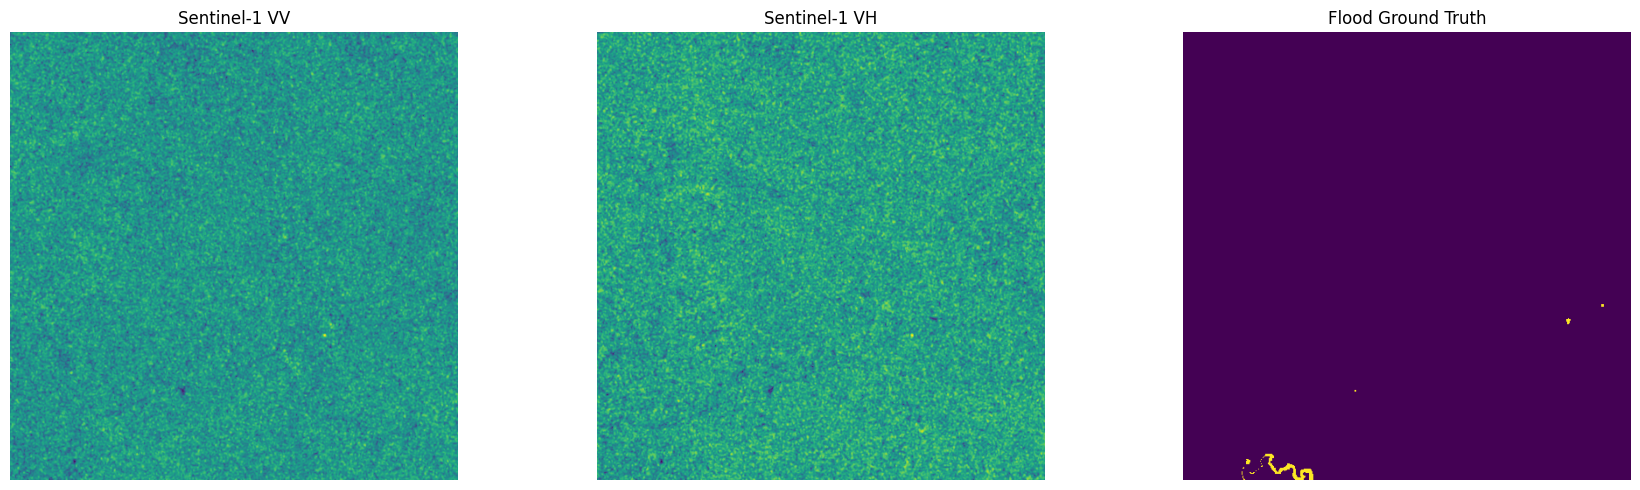

In [41]:
# ------------------------------------------------------------
# F-01 | Visualize one satellite sample
# ------------------------------------------------------------
# We display:
#
# 1. Sentinel-1 VV
# 2. Sentinel-1 VH
# 3. Flood ground-truth label
#
# This is the first time we visually connect the numerical
# satellite observations with the flood ground truth.
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# VV polarization
axes[0].imshow(vv)
axes[0].set_title("Sentinel-1 VV")
axes[0].axis("off")

# VH polarization
axes[1].imshow(vh)
axes[1].set_title("Sentinel-1 VH")
axes[1].axis("off")

# Flood label
axes[2].imshow(flood_label)
axes[2].set_title("Flood Ground Truth")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [42]:
# ------------------------------------------------------------
# F-01 | Verify spatial alignment
# ------------------------------------------------------------
# For pixel-level segmentation, the input image and label
# must correspond spatially.
#
# We compare:
#   - dimensions
#   - CRS
#   - geographic bounds
# ------------------------------------------------------------

with rasterio.open(s1_local_path) as s1_src:
    s1_shape = (s1_src.height, s1_src.width)
    s1_crs = s1_src.crs
    s1_bounds = s1_src.bounds

with rasterio.open(label_local_path) as label_src:
    label_shape = (label_src.height, label_src.width)
    label_crs = label_src.crs
    label_bounds = label_src.bounds

print("Dimensions")
print("Sentinel-1:", s1_shape)
print("Label     :", label_shape)

print("\nCRS")
print("Sentinel-1:", s1_crs)
print("Label     :", label_crs)

print("\nBounds equal?")
print(s1_bounds == label_bounds)

Dimensions
Sentinel-1: (512, 512)
Label     : (512, 512)

CRS
Sentinel-1: EPSG:4326
Label     : EPSG:4326

Bounds equal?
True


In [43]:
# ------------------------------------------------------------
# F-01 | Inspect spatial resolution
# ------------------------------------------------------------
# Resolution tells us approximately how much ground distance
# one pixel represents.
# ------------------------------------------------------------

with rasterio.open(s1_local_path) as src:

    print("Pixel resolution:")
    print("X resolution:", src.res[0])
    print("Y resolution:", src.res[1])

    print("\nCoordinate Reference System:")
    print(src.crs)

Pixel resolution:
X resolution: 8.983152841195215e-05
Y resolution: 8.983152841195215e-05

Coordinate Reference System:
EPSG:4326


In [44]:
# ------------------------------------------------------------
# F-01 | Estimate chip ground dimensions
# ------------------------------------------------------------
# We estimate the ground coverage represented by the image.
#
# This helps translate:
#   pixels → physical geographic area
# ------------------------------------------------------------

with rasterio.open(s1_local_path) as src:

    width = src.width
    height = src.height
    pixel_width = abs(src.res[0])
    pixel_height = abs(src.res[1])

    print("Image size:")
    print("Width :", width, "pixels")
    print("Height:", height, "pixels")

    print("\nApproximate pixel size:")
    print("X:", pixel_width)
    print("Y:", pixel_height)

Image size:
Width : 512 pixels
Height: 512 pixels

Approximate pixel size:
X: 8.983152841195215e-05
Y: 8.983152841195215e-05


In [45]:
# ------------------------------------------------------------
# F-01 | Sample-level research summary
# ------------------------------------------------------------
# This cell collects the important observations from the
# sample into one compact summary.
# ------------------------------------------------------------

sample_summary = {
    "Sentinel-1 file": first_s1_file,
    "Label file": first_label_file,
    "Image height": vv.shape[0],
    "Image width": vv.shape[1],
    "Sentinel-1 bands": 2,
    "VV dtype": str(vv.dtype),
    "VH dtype": str(vh.dtype),
    "Label dtype": str(flood_label.dtype),
    "Valid label pixels": int(valid_count),
    "Water pixels": int(water_count),
    "Non-water pixels": int(non_water_count),
    "Water percentage": round(float(water_percentage), 2),
}

sample_summary

{'Sentinel-1 file': 'Ghana_24858_S1Hand.tif',
 'Label file': 'Ghana_24858_LabelHand.tif',
 'Image height': 512,
 'Image width': 512,
 'Sentinel-1 bands': 2,
 'VV dtype': 'float32',
 'VH dtype': 'float32',
 'Label dtype': 'int16',
 'Valid label pixels': 262144,
 'Water pixels': 484,
 'Non-water pixels': 261660,
 'Water percentage': 0.18}

In [46]:
# ------------------------------------------------------------
# F-01 | Validate filename pairing across training data
# ------------------------------------------------------------
# We check whether every training record appears to contain:
#
#   <same event/chip>_S1Hand.tif
#   <same event/chip>_LabelHand.tif
#
# This is a structural consistency check.
# ------------------------------------------------------------

s1_column = train_df.columns[0]
label_column = train_df.columns[1]

print("Sentinel-1 column:", s1_column)
print("Label column     :", label_column)

print("\nTraining rows:", len(train_df))

# Display a few pairs side by side
display(train_df[[s1_column, label_column]].head(10))

Sentinel-1 column: Ghana_103272_S1Hand.tif
Label column     : Ghana_103272_LabelHand.tif

Training rows: 251


,Ghana_103272_S1Hand.tif,Ghana_103272_LabelHand.tif
0,Ghana_24858_S1Hand.tif,Ghana_24858_LabelHand.tif
1,Ghana_147015_S1Hand.tif,Ghana_147015_LabelHand.tif
2,Ghana_953791_S1Hand.tif,Ghana_953791_LabelHand.tif
3,Ghana_154838_S1Hand.tif,Ghana_154838_LabelHand.tif
4,Ghana_134751_S1Hand.tif,Ghana_134751_LabelHand.tif
5,Ghana_61925_S1Hand.tif,Ghana_61925_LabelHand.tif
6,Ghana_156478_S1Hand.tif,Ghana_156478_LabelHand.tif
7,Ghana_144050_S1Hand.tif,Ghana_144050_LabelHand.tif
8,Ghana_49890_S1Hand.tif,Ghana_49890_LabelHand.tif
9,Ghana_97516_S1Hand.tif,Ghana_97516_LabelHand.tif


In [47]:
# ------------------------------------------------------------
# F-01 | Check S1/Label filename pairing
# ------------------------------------------------------------
# We remove the layer-specific suffix from each filename.
#
# Example:
#   Ghana_103272_S1Hand.tif
#   Ghana_103272_LabelHand.tif
#
# should share the same sample identifier:
#   Ghana_103272
# ------------------------------------------------------------

s1_names = (
    train_df[s1_column]
    .astype(str)
    .str.replace("_S1Hand.tif", "", regex=False)
)

label_names = (
    train_df[label_column]
    .astype(str)
    .str.replace("_LabelHand.tif", "", regex=False)
)

pairing_matches = s1_names == label_names

print("Matching sample identifiers:",
      pairing_matches.sum())

print("Non-matching identifiers:",
      (~pairing_matches).sum())

Matching sample identifiers: 251
Non-matching identifiers: 0


In [48]:
# ------------------------------------------------------------
# F-01 | Check duplicate sample identifiers
# ------------------------------------------------------------
# A sample identifier should normally identify one chip.
# We check whether the same identifier appears multiple times.
# ------------------------------------------------------------

duplicate_ids = s1_names[s1_names.duplicated(keep=False)]

print("Number of duplicate training identifiers:",
      duplicate_ids.nunique())

if len(duplicate_ids) > 0:
    print("\nDuplicate identifiers:")
    print(duplicate_ids.tolist())
else:
    print("No duplicate training sample identifiers found.")

Number of duplicate training identifiers: 0
No duplicate training sample identifiers found.


In [49]:
# ------------------------------------------------------------
# F-01 | Extract event/country names
# ------------------------------------------------------------
# Sen1Floods11 filenames begin with the event/country name.
#
# Example:
#   Ghana_103272_S1Hand.tif
#
# Here "Ghana" is the event prefix.
#
# This is only a preliminary filename-based grouping.
# Later we should use the official metadata GeoJSON for
# authoritative event information.
# ------------------------------------------------------------

event_prefix = (
    train_df[s1_column]
    .astype(str)
    .str.split("_")
    .str[0]
)

print("Training samples by filename prefix:")
print(event_prefix.value_counts())

Training samples by filename prefix:
Ghana_103272_S1Hand.tif
USA          41
India        40
Paraguay     39
Ghana        30
Sri-Lanka    24
Mekong       18
Spain        18
Pakistan     16
Somalia      15
Nigeria      10
Name: count, dtype: int64


In [50]:
# ------------------------------------------------------------
# F-01 | Download Sen1Floods11 event metadata
# ------------------------------------------------------------
# The official metadata GeoJSON contains information about
# the flood events represented in the dataset.
#
# We download this small metadata file rather than the entire
# satellite dataset.
# ------------------------------------------------------------

METADATA_REMOTE = (
    "gs://sen1floods11/v1.1/"
    "Sen1Floods11_Metadata.geojson"
)

METADATA_LOCAL = (
    "/content/sen1floods11/"
    "Sen1Floods11_Metadata.geojson"
)

!gsutil cp "$METADATA_REMOTE" "$METADATA_LOCAL"

print("Metadata downloaded:")
print(METADATA_LOCAL)

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/Sen1Floods11_Metadata.geojson...
/ [1 files][ 13.8 KiB/ 13.8 KiB]                                                
Operation completed over 1 objects/13.8 KiB.                                     
Metadata downloaded:
/content/sen1floods11/Sen1Floods11_Metadata.geojson


In [51]:
# ------------------------------------------------------------
# F-01 | Inspect event metadata
# ------------------------------------------------------------
# GeoJSON is a geographic JSON format.
# GeoPandas allows us to inspect its geographic features.
# ------------------------------------------------------------

import geopandas as gpd

metadata_gdf = gpd.read_file(METADATA_LOCAL)

print("Metadata shape:", metadata_gdf.shape)

print("\nMetadata columns:")
print(metadata_gdf.columns.tolist())

print("\nFirst records:")
display(metadata_gdf.head())

Metadata shape: (12, 12)

Metadata columns:
['coincident_size', 'location', 'orbit', 'rel_orbit_num', 's1_date', 's2_date', 'ID', 'ISO_CC', 'VH_thresh', 'train_chip', 'val_chip', 'geometry']

First records:


,coincident_size,location,orbit,rel_orbit_num,s1_date,s2_date,ID,ISO_CC,VH_thresh,train_chip,val_chip,geometry
0,10.0,Bolivia,DESCENDING,156.0,2018-02-15,2018-02-15,1,BOL,-20.44,224,15,"POLYGON ((-65.31756 -15.95924, -65.15825 -15.95924, -64.99895 -15.95924, -64.83964 -15.95924, -64.68034 -15.95924, -64.52103 -15.95924, -64.36164 -15.95924, -64.36164 -11.39104, -64.52103 -11.3910..."
1,17.0,Colombia,ASCENDING,106.0,2018-08-22,2018-08-23,12,COL,-21.31,534,0,"POLYGON ((-66.69906 2.11019, -66.69897 2.11026, -66.69897 7.10168, -66.98628 7.10168, -67.27351 7.10168, -67.56073 7.10168, -67.84796 7.10168, -68.13518 7.10168, -68.42241 7.10168, -68.70963 7.101..."
2,23.0,Ghana,ASCENDING,147.0,2018-09-18,2018-09-19,2,GHA,-22.81,181,53,"POLYGON ((-2.30324 6.30595, -2.14561 6.30595, -1.9093 6.30593, -1.59423 6.30593, -1.27916 6.30593, -0.96409 6.30593, -0.64901 6.30593, -0.33394 6.30593, -0.01887 6.30593, 0.21753 6.30595, 0.21753 ..."
3,12.0,India,DESCENDING,77.0,2016-08-12,2016-08-12,3,IND,-21.56,467,68,"POLYGON ((92.27653 28.28476, 92.15065 28.28476, 92.15065 24.84718, 92.33943 24.84714, 92.59099 24.84714, 92.84255 24.84714, 93.09411 24.84714, 93.34567 24.84714, 93.59724 24.84714, 93.78591 24.847..."
4,16.0,Cambodia,ASCENDING,26.0,2018-08-05,2018-08-04,4,KHM,-23.06,1353,30,"POLYGON ((106.27974 10.57124, 106.42678 10.57124, 106.42678 14.2749, 106.13278 14.2749, 105.83888 14.2749, 105.39802 14.2749, 104.95716 14.2749, 104.66325 14.2749, 104.36935 14.2749, 104.07535 14...."


In [52]:
# ------------------------------------------------------------
# F-01 | Inspect metadata information
# ------------------------------------------------------------
# We inspect:
#   - number of flood events
#   - coordinate reference system
#   - available attributes
# ------------------------------------------------------------

print("Number of metadata features:", len(metadata_gdf))

print("\nCRS:")
print(metadata_gdf.crs)

print("\nAvailable metadata fields:")
for column in metadata_gdf.columns:
    print("-", column)

Number of metadata features: 12

CRS:
EPSG:4326

Available metadata fields:
- coincident_size
- location
- orbit
- rel_orbit_num
- s1_date
- s2_date
- ID
- ISO_CC
- VH_thresh
- train_chip
- val_chip
- geometry


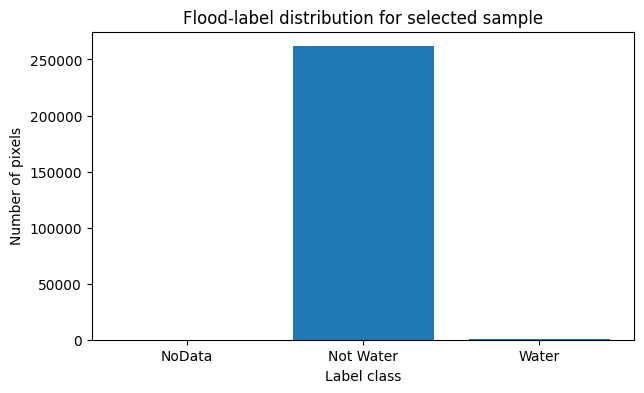

In [53]:
# ------------------------------------------------------------
# F-01 | Visualize label distribution
# ------------------------------------------------------------
# We visualize the number of pixels belonging to each label.
# ------------------------------------------------------------

labels = [-1, 0, 1]
label_names = ["NoData", "Not Water", "Water"]

counts = [
    np.sum(flood_label == label_value)
    for label_value in labels
]

plt.figure(figsize=(7, 4))

plt.bar(label_names, counts)

plt.xlabel("Label class")
plt.ylabel("Number of pixels")
plt.title("Flood-label distribution for selected sample")

plt.show()

In [54]:
# ------------------------------------------------------------
# F-01 | Create valid-pixel mask
# ------------------------------------------------------------
# -1 represents NoData in the Sen1Floods11 hand labels.
#
# We create a Boolean mask so that later calculations can
# exclude invalid pixels.
# ------------------------------------------------------------

valid_mask = flood_label != -1

print("Total pixels:", flood_label.size)
print("Valid pixels:", valid_mask.sum())
print("NoData pixels:", (~valid_mask).sum())

Total pixels: 262144
Valid pixels: 262144
NoData pixels: 0


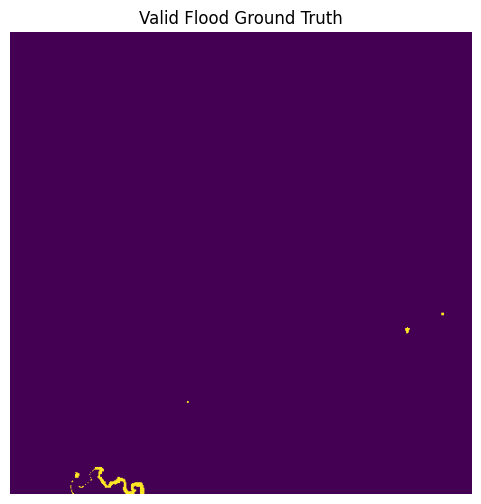

In [55]:
# ------------------------------------------------------------
# F-01 | Visualize valid flood labels
# ------------------------------------------------------------
# NoData pixels are masked so that the visualization focuses
# on actual ground-truth classes.
# ------------------------------------------------------------

display_label = np.ma.masked_where(
    flood_label == -1,
    flood_label
)

plt.figure(figsize=(7, 6))

plt.imshow(display_label)

plt.title("Valid Flood Ground Truth")
plt.axis("off")

plt.show()

In [56]:
# ------------------------------------------------------------
# F-01 | Final observation summary
# ------------------------------------------------------------
# This cell prints the main facts discovered during the
# inspection stage.
#
# IMPORTANT:
# These are observations, not model-performance claims.
# ------------------------------------------------------------

print("F-01 — Sen1Floods11 Data Inspection")
print("=" * 60)

print("\nDataset split sizes")
print("Train      :", len(train_df))
print("Validation :", len(valid_df))
print("Test       :", len(test_df))
print("Bolivia    :", len(bolivia_df))

print("\nSelected sample")
print("S1 file    :", first_s1_file)
print("Label file :", first_label_file)

print("\nSentinel-1")
print("Shape      :", vv.shape)
print("Bands      :", 2)
print("Datatype   :", vv.dtype)

print("\nFlood label")
print("Shape      :", flood_label.shape)
print("Datatype   :", flood_label.dtype)

print("\nLabel classes observed")
for value, count in zip(label_values, label_counts):
    print(f"Class {value}: {count} pixels")

print("\nWater coverage:")
print(f"{water_percentage:.2f}% of valid pixels")

print("\nF-01 status:")
print("Data inspection completed for one sample.")

F-01 — Sen1Floods11 Data Inspection

Dataset split sizes
Train      : 251
Validation : 88
Test       : 89
Bolivia    : 14

Selected sample
S1 file    : Ghana_24858_S1Hand.tif
Label file : Ghana_24858_LabelHand.tif

Sentinel-1
Shape      : (512, 512)
Bands      : 2
Datatype   : float32

Flood label
Shape      : (512, 512)
Datatype   : int16

Label classes observed
Class 0: 261660 pixels
Class 1: 484 pixels

Water coverage:
0.18% of valid pixels

F-01 status:
Data inspection completed for one sample.
